In [1]:
'''TODO EARLY STOPPING, SELF/CROSS ATTENTION IN AUTO ENCODER, BLOCKING ON ALGS OR PASSWORDS OR SOURCES, REGULARIZATION ON LAYERS AND/OR SEPERATE NORMALIZATION LAYERS'''
'''potentially add stuff for tau statistics (scipy function avalible) and actually do the lil histograms and stuff'''
'''TODO add fancier plots for comparing and the training history of the models'''
from ollama import chat
from ollama import ChatResponse
import secrets
from Crypto.Cipher import AES
from sklearn.cluster import SpectralClustering
from sklearn.model_selection import train_test_split
from Crypto.Cipher import AES
from Crypto.Hash import SHAKE128
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPool2D, Attention, Normalization, Reshape, Conv2DTranspose, MultiHeadAttention, BatchNormalization, Activation
import polars as pl
import os
from Crypto.Util.Padding import pad, unpad
import math
from keras import Model, Input, Sequential
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import plotly.express as px
from keras.callbacks import EarlyStopping
import plotly.graph_objects as go
from scipy.stats import kendalltau
from random import randint
import copy
from plotly.subplots import make_subplots

2025-04-23 19:46:09.825919: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-23 19:46:09.841900: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-23 19:46:09.846505: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-23 19:46:09.857870: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import subprocess

def run_bes512_encrypt(plaintext: bytes, key_bytes: bytes, iv_bytes: bytes, rounds: int, enc_or_dec: str = 'enc') -> bytes:
    try:
        # Format CLI arguments
        args = [
            "./target/debug/bes-512",
            "-m", "CBC",
            "-c", "BES-512",
            "-k", '0x' + key_bytes.hex(),           # assuming you can pass hex directly instead of a file
            "-i", '0x' + iv_bytes.hex(),
            "--bes-rounds", str(rounds),
            enc_or_dec
        ]
        
        # Run the command, send plaintext via stdin
        result = subprocess.run(
            args,
            input=plaintext,
            capture_output=True,
            check=True
        )
        
        return result.stdout  # Raw encrypted bytes
    except subprocess.CalledProcessError as e:
        print("Encryption failed:", e.stderr.decode())
        return b''

# Example usage:
# plaintext = b"In a hole in the ground there lived a hobbit... - Bilbo Baggins"
# key = b"\x00" * 64  # 512-bit key (64 bytes)
# iv = b"\x01" * 64   # Typical 128-bit IV (adjust if your implementation uses a different size)
# rounds = 14

# ciphertext = run_bes512_encrypt(plaintext, key, iv, rounds, 'enc')
# print("Encrypted (bytes):", ciphertext)
# plaintext_gen = run_bes512_encrypt(ciphertext, key, iv, rounds, 'dec')
# print(plaintext_gen)


In [3]:
# test_text = b"test text" 
# test = !echo 'In a hole in the ground there lived a hobbit... - Bilbo Baggins' | ./target/debug/bes-512 -m CBC -c BES-512 -k ./512-bits.key enc

In [4]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


I0000 00:00:1745459173.755915  284959 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745459173.804463  284959 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745459173.804752  284959 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


In [5]:
from dataclasses import dataclass, field
import re
from typing import Optional

@dataclass
class Algorithm:
    name: str
    pass_dict: dict
    iv: bytes
    rounds: Optional[int] = None  # Optional input
    has_rounds: bool = False

    def __post_init__(self):
        if self.rounds is not None:
            # User manually provided round count
            self.has_rounds = True


In [6]:
'''Passwords & Hashes'''
passwords = [b"Andromeda", b"Neptune", b"Jupiter", b"Saturn"]
algs= ['128', '256', '512r1', '512r16'] #be sure to add 512 eventually
hash128 = {password: SHAKE128.new(password).read(128 // 8) for password in passwords}
hash256 = {password: SHAKE128.new(password).read(256 // 8) for password in passwords}
hash512 = {password: SHAKE128.new(password).read(512 // 8) for password in passwords}
iv_start = b"static iv"
# iv_16 = secrets.token_bytes(16) # used for standard AES
# iv_64 = secrets.token_bytes(64)
iv_16 = SHAKE128.new(iv_start).read(16)
iv_64 = SHAKE128.new(iv_start).read(64)
# hash128['iv'] = iv_16
# hash256['iv'] = iv_16
# hash512['iv'] = iv_64
print(hash512[b'Andromeda'])
print(hash128)
algs = [Algorithm('128', hash128, iv=iv_16), Algorithm('256', hash256, iv=iv_16), Algorithm('512r1', hash512, iv=iv_64, rounds=1), Algorithm('512r16', hash512, iv=iv_64, rounds=16)]

b"p\x17Y{\xbc\x82\x06\xb7\tr\xd7\xeb)~\xf4\x00%\xf0R\xf73NF\xb3\x86\xd2\x9dJ\x84\x9b(^\x8c\xc3a\x93\xf2\xca\xc6\xafI\xaf\x93\x1f\xe6\x8d\x05)\xb5\xa1\x08\x86X\x02\xc9'\x07\x84\xf3bl\\\x99f"
{b'Andromeda': b'p\x17Y{\xbc\x82\x06\xb7\tr\xd7\xeb)~\xf4\x00', b'Neptune': b'\xe3\xbc\xf4\x89\xd6\x13I4\xe9\x08&\xfd\xe2a[#', b'Jupiter': b'/Z\xd0\xd26\x95\x9b\xe5u\x9bs\xbcub-\x86', b'Saturn': b'L4 \xab\x95\n\xb2\xffM\x14O-\xf1\xe2a\x14'}


In [7]:
print(algs[0])

Algorithm(name='128', pass_dict={b'Andromeda': b'p\x17Y{\xbc\x82\x06\xb7\tr\xd7\xeb)~\xf4\x00', b'Neptune': b'\xe3\xbc\xf4\x89\xd6\x13I4\xe9\x08&\xfd\xe2a[#', b'Jupiter': b'/Z\xd0\xd26\x95\x9b\xe5u\x9bs\xbcub-\x86', b'Saturn': b'L4 \xab\x95\n\xb2\xffM\x14O-\xf1\xe2a\x14'}, iv=b'$\xcb\xa4\x88\x13\x1e\xb3\x8d\x17y\x8d\xa0\xe8\xfa$\xc3', rounds=None, has_rounds=False)


In [8]:
def encrypt_portion(alg: Algorithm, password, plaintext):
    ciphertext = ''
    if not alg.has_rounds:
        ciphertext = AES.new(password, AES.MODE_CBC, iv=alg.iv).encrypt(pad(plaintext, 512 // 8, 'iso7816'))
    else:
        ciphertext = run_bes512_encrypt(plaintext, password, alg.iv, alg.rounds, 'enc')
    return ciphertext

In [9]:
def plot_training(history, name = ''):
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Loss", "Accuracy"))
    # Plot Loss
    epochs = [x for x in range(len(history['loss']))]
    fig.add_trace(go.Scatter(
        x=epochs, y=history['loss'],
        mode='lines+markers', name='Training Loss',
        line=dict(color='royalblue')
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=epochs, y=history['val_loss'],
        mode='lines+markers', name='Validation Loss',
        line=dict(color='lightblue')
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=epochs, y=history['accuracy'],
        mode='lines+markers', name='Training Accuracy',
        line=dict(color='seagreen')
    ), row=1, col=2)

    fig.add_trace(go.Scatter(
        x=epochs, y=history['val_accuracy'],
        mode='lines+markers', name='Validation Accuracy',
        line=dict(color='lightgreen')
    ), row=1, col=2)

    fig.update_layout(
        title_text=name + "Training History",
        xaxis_title="Epoch",
        yaxis_title="Loss/Accuracy",
        height=500,
        width=900,
        legend=dict(x=0.5, y=-0.2, orientation="h", xanchor="center"),
        margin=dict(t=50, b=100)
    )
    return fig

In [10]:
'''Encrypt Messages'''
'''need all ciphertexts to be the same size, maybe just set a block limit based on the shortest message length?'''
'''add a variable for blocks per data point, could prolly start with three so we get a lot more data'''
'''do i need to do a password prediction variant where it actually tries to predict the password value as oppossed to the numeric label'''
'''give it a worl'''
#should only need to be done once
def encryptMessages(alg, max_blocks, blocks_per_point):
    max_bytes = (max_blocks * 512) // 8 #should be a perfect division anyways
    byte_range_len = (blocks_per_point * 512) // 8
    points_per_file = max_bytes // byte_range_len
    passwords = list(alg.pass_dict.keys())
    for (root, dirs, files) in os.walk("../HumanReadable"):
        for file in files:
            with open(f'../HumanReadable/{file}', 'rb') as plaintextstore:
                plaintext = plaintextstore.read()
                for byte_range in range(points_per_file):
                    for password in passwords:
                        #print(len(pass_dict[password]))
                        with open(f'../{alg.name}ciphertext/{alg.name}_{password}_{file}_{byte_range}', 'wb') as cipherstore:
                            #ciphertext = AES.new(pass_dict[password], AES.MODE_ECB).encrypt(pad(plaintext[byte_range * byte_range_len:(byte_range+1)*byte_range_len], 512, 'iso7816'))
                            plaintext_portion = plaintext[byte_range * byte_range_len:(byte_range+1)*byte_range_len]
                            # if len(plaintext_portion) != 192:
                            #     print(len(plaintext_portion))
                            ciphertext = encrypt_portion(alg, alg.pass_dict[password], plaintext_portion)
                            # if len(ciphertext) != 256:
                            #     print(len(ciphertext))
                            cipherstore.write(ciphertext)
#not most blocks present but most blocks to use = num blocks in shortest message
max_blocks = 1000
image_shape = [8, 8]
for (root, dirs, files) in os.walk("../HumanReadable"):
    for file in files:
        with open(f'../HumanReadable/{file}', 'rb') as plaintextstore:
            plaintext = plaintextstore.read()
            if math.floor((len(plaintext) * 8) / 512) < max_blocks:
                max_blocks = math.floor((len(plaintext) * 8) / 512)
blocks_per_point = 3
print(math.sqrt((512 * blocks_per_point) / 8))
img_size = (512 * blocks_per_point) // 8 + (512 // 8) #need to add the extra padding
s = math.floor(math.sqrt(img_size))
l = s
w = s
r = img_size - (l*w)
while r != 0:
    l -= 1
    w = math.floor(img_size / l)
    r = img_size - (l*w)
image_shape = [l,w]
'''CHANGE FOR COMBO APPROACH'''
#image_shape.append(1)
image_shape.append(2)
image_shape = tuple(image_shape)
print(blocks_per_point, image_shape)
assert(image_shape[0] * image_shape[1] == (512 * blocks_per_point) / 8 + 64)
# encryptMessages('128', hash128, max_blocks, blocks_per_point)
# encryptMessages('256', hash256, max_blocks, blocks_per_point)
for alg in algs:
    encryptMessages(alg, max_blocks, blocks_per_point)

13.856406460551018
3 (16, 16, 2)


In [75]:
'''ONLY FOR MID RUN CHANGE'''
image_shape = (image_shape[0], image_shape[1], 1)
x_string = 'ciphertext'

In [76]:
'''Compile Training Data'''
columns = ['alg', 'password', 'source_file', 'plaintext', 'ciphertext', 'combo_text']
data = []
#image size is greater than plaintext ize due to padding an extra block
max_bytes = (max_blocks * 512) // 8
byte_range_len = (blocks_per_point * 512) // 8
points_per_file = math.floor(max_bytes / byte_range_len)
for alg in algs:
    for password in passwords:
        for (root, dirs, files) in os.walk("../HumanReadable"):
            for source_file in files:
                for byte_range in range(points_per_file):
                    with open(f'../HumanReadable/{source_file}', 'rb') as plaintextstore:
                        plaintext = plaintextstore.read()
                        plaintext_portion = plaintext[byte_range_len*byte_range:(byte_range+1)*byte_range_len]
                        plaintext_pad = pad(plaintext_portion, 512 // 8, 'iso7816')
                        plaintextimage = [[[int(byte)/255] for byte in plaintext_pad[row*image_shape[0] : row*image_shape[0] + image_shape[1]]] for row in range(image_shape[0])]
                        with open(f'../{alg.name}ciphertext/{alg.name}_{password}_{source_file}_{byte_range}', 'rb') as cipherstore:
                            ciphertext = cipherstore.read()
                            #print(len(ciphertext))
                            #normalize and want (l,w,d) shape
                            #print(len(ciphertext))
                            assert(len(ciphertext) == img_size)
                            ciphertextimage = [[[int(byte)/255] for byte in ciphertext[row*image_shape[0] : row*image_shape[0] + image_shape[1]]] for row in range(image_shape[0])]
                            assert(len(ciphertextimage) == image_shape[0])
                            assert(len(ciphertextimage[0]) == image_shape[1])
                            #assert(len(ciphertextimage[0][0]) == image_shape[2])
                            combo_text = [[[ciphertextimage[i][j][0], plaintextimage[i][j][0]]for j in range(len(ciphertextimage[0]))]for i in range(len(ciphertextimage))]
                            #ciphertextimagearray = np.asarray(ciphertextimage, np.float32)
                            # plaintext_portion = plaintext[byte_range_len*byte_range:(byte_range+1)*byte_range_len]
                            # plaintextimage = [[[int(byte)/255] for byte in plaintext_portion[row*image_shape[0] : row*image_shape[0] + image_shape[1]]] for row in range(image_shape[0])]
                            #plaintextimagearray = np.asarray(plaintextimage, np.float32)
                            #entire ciphertext file is valid but must split plaintext
                            #make sure to fill in leading zeros
                            #plaintext_bits = [list(bin(int(byte))[2:].zfill(8)) for byte in plaintext_portion]
                            #ciphertext_bits = [list(bin(int(byte))[2:].zfill(8)) for byte in ciphertext]
                            data.append([alg.name, password, source_file + f'_{byte_range}', plaintext_portion, ciphertextimage, combo_text])

df = pl.LazyFrame(data, columns, orient='row')
df = df.collect()
df = df.sample(fraction=1, shuffle= True)
#df = df.to_dummies(columns[:-2])
train_size = math.floor( .9 * len(df))
test_size = len(df) - train_size
# x_string = 'combo_text'
train, test = df.head(train_size), df.tail(test_size)
train_data, test_data = train[x_string], test[x_string]
train_targets, test_targets = train.select(pl.exclude(x_string)), test.select(pl.exclude(x_string))

In [77]:
print(df)

shape: (38_400, 6)
┌────────┬──────────────┬──────────────────┬──────────────────┬──────────────────┬─────────────────┐
│ alg    ┆ password     ┆ source_file      ┆ plaintext        ┆ ciphertext       ┆ combo_text      │
│ ---    ┆ ---          ┆ ---              ┆ ---              ┆ ---              ┆ ---             │
│ str    ┆ binary       ┆ str              ┆ binary           ┆ list[list[list[f ┆ list[list[list[ │
│        ┆              ┆                  ┆                  ┆ 64]]]            ┆ f64]]]          │
╞════════╪══════════════╪══════════════════╪══════════════════╪══════════════════╪═════════════════╡
│ 256    ┆ b"Jupiter"   ┆ Convo9Message1_2 ┆ b"ey\x20\xe2\x80 ┆ [[[0.243137],    ┆ [[[0.243137,    │
│        ┆              ┆                  ┆ \x93\x20this\x…  ┆ [0.047059], …    ┆ 0.396078],      │
│        ┆              ┆                  ┆                  ┆ [0…              ┆ [0.047…         │
│ 128    ┆ b"Andromeda" ┆ Convo37Message1_ ┆ b"ponentially.\x ┆ [[[0.815

In [78]:
for x in train_data.to_list():
    if len(x) != image_shape[0]:
        print('1st',x)
    for y in x:
        if len(y) != image_shape[1]:
            print('2nd', y)
        for z in y:
            if len(z) != image_shape[2]:
                print('3rd', z)

In [79]:
train_data_format = np.array(train_data.to_list())
test_data_format = np.array(test_data.to_list())
sources = df['source_file'].unique()
print(sources)

shape: (2_400,)
Series: 'source_file' [str]
[
	"Convo35Message1_0"
	"Convo38Message3_10"
	"Convo15Message2_4"
	"Convo15Message2_8"
	"Convo31Message0_7"
	…
	"Convo29Message1_0"
	"Convo8Message0_3"
	"Convo5Message3_9"
	"Convo5Message1_5"
	"Convo6Message1_4"
]


In [80]:
def make_mapping(data, enum_vals, col_name):
    mapping = {enum_val: i for i, enum_val in enumerate(enum_vals)}
    mapped_data = data.with_columns(
    pl.col(col_name).replace_strict(mapping)
    )
    return mapped_data, mapping

In [81]:
print(train_targets.head())

shape: (5, 5)
┌────────┬──────────────┬────────────────────┬──────────────────────────┬──────────────────────────┐
│ alg    ┆ password     ┆ source_file        ┆ plaintext                ┆ combo_text               │
│ ---    ┆ ---          ┆ ---                ┆ ---                      ┆ ---                      │
│ str    ┆ binary       ┆ str                ┆ binary                   ┆ list[list[list[f64]]]    │
╞════════╪══════════════╪════════════════════╪══════════════════════════╪══════════════════════════╡
│ 256    ┆ b"Jupiter"   ┆ Convo9Message1_2   ┆ b"ey\x20\xe2\x80\x93\x20 ┆ [[[0.243137, 0.396078],  │
│        ┆              ┆                    ┆ this\x…                  ┆ [0.047…                  │
│ 128    ┆ b"Andromeda" ┆ Convo37Message1_8  ┆ b"ponentially.\x0a\x0aMy ┆ [[[0.815686, 0.439216],  │
│        ┆              ┆                    ┆ \x20ca…                  ┆ [0.113…                  │
│ 256    ┆ b"Saturn"    ┆ Convo33Message0_1  ┆ b"dicted\x20parameters.\ ┆ [[[

In [82]:
'''Autoencoder'''
'''normalization before attention, batch normalization before convolution'''
'''CNN -> batchnormalize -> activation -> dropout'''
'''normalization -> attention -> dropout'''
#is mean pooling worth investigating
#will need to play around with amount of parameters
#should i include more than just the ciphertext?
encoder_input = Input(shape=image_shape)
#4x4 byte matrix is AES operator size seems fitting
#blocks*4 is the amount of AES-128 blocks which seems like a decent starting metric
encoder = Conv2D(max_blocks*4, (4,4), padding='same')(encoder_input)
encoder = BatchNormalization(axis=-1)(encoder)
encoder = Activation('relu')(encoder)
encoder = Dropout(.5)(encoder)
encoder = MaxPool2D(pool_size=(4,4), strides=4)(encoder)
encoder = BatchNormalization(axis=-1)(encoder)

encoder = Conv2D(max_blocks, (4,4), padding='same', activation='relu')(encoder)
encoder = BatchNormalization(axis=-1)(encoder)
encoder = Activation('relu')(encoder)
encoder = Dropout(.5)(encoder)
encoder = MaxPool2D(pool_size=(2,2), strides=4)(encoder)
encoder_attended = Normalization(axis = -1)(encoder)
'''maybe try cross attention?'''
encoder_attention = MultiHeadAttention(num_heads=4, key_dim=16)(encoder_attended, encoder_attended)
encoder = Dropout(.5)(encoder_attention)
encoder = Flatten()(encoder)
embedded_layer = Dense(3, activation='relu')(encoder)
decoder1 = Dense(4, activation='relu')(embedded_layer)
decoder2 = Reshape((2,2,1))(decoder1)
decoder3 = Conv2DTranspose(max_blocks, (2,2), strides = (l // 2,w // 2), padding='same', activation='relu')(decoder2)
#decoder3 = Conv2DTranspose(max_blocks * 4, (2,2), strides = (l // 2,w // 2), padding='same', activation='relu')(decoder2)
decoder4 = Conv2D(image_shape[2], (4, 4), activation="sigmoid", padding="same")(decoder3)

autoencoder = Model(encoder_input, decoder4)
encoder = Model(encoder_input, embedded_layer)


In [83]:
autoencoder.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 16, 16, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 16, 16,    │      2,584 │ input_layer_7[0]… │
│                     │ 152)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        608 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 152)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 152)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_28          │ (None, 16, 16,    │          0 │ activation_14[0]… │
│ (Dropout)           │ 152)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 4, 4, 152) │          0 │ dropout_28[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 4, 152) │        608 │ max_pooling2d_14… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 4, 4, 38)  │     92,454 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 4, 38)  │        152 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 4, 4, 38)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_29          │ (None, 4, 4, 38)  │          0 │ activation_15[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 1, 1, 38)  │          0 │ dropout_29[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_7     │ (None, 1, 1, 38)  │         77 │ max_pooling2d_15… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 1, 38)  │      9,958 │ normalization_7[… │
│ (MultiHeadAttentio… │                   │            │ normalization_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_31          │ (None, 1, 1, 38)  │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 38)        │          0 │ dropout_31[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 3)         │        117 │ flatten_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 4)         │         16 │ dense_9[0][0]   

 Total params: 107,373 (419.43 KB)

 Trainable params: 106,612 (416.45 KB)

 Non-trainable params: 761 (2.98 KB)

In [84]:
'''keras example uses binary_crossentropy but they also had binary images, description says its for binary classification though'''
'''mse as alternate'''
autoencoder.compile(optimizer="adam", loss="binary_crossentropy", metrics=['accuracy'])
autoencoder_callback = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
encoder_hist = autoencoder.fit(train_data_format, train_data_format, epochs = 200, callbacks=[autoencoder_callback], validation_split=.1)

Epoch 1/200
972/972 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.0041 - loss: 0.6930 - val_accuracy: 0.0041 - val_loss: 0.6928
Epoch 2/200
972/972 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0042 - loss: 0.6925 - val_accuracy: 0.0041 - val_loss: 0.6927
Epoch 3/200
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.0042 - loss: 0.6924 - val_accuracy: 0.0041 - val_loss: 0.6928
Epoch 4/200
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.0042 - loss: 0.6923 - val_accuracy: 0.0041 - val_loss: 0.6926
Epoch 5/200
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.0042 - loss: 0.6923 - val_accuracy: 0.0041 - val_loss: 0.6926
Epoch 6/200
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.0042 - loss: 0.6923 - val_accuracy: 0.0041 - val_loss: 0.6927
Epoch 7/200
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.0042 - loss: 0.6923 - val_accuracy: 0.0041 - val_loss: 0.6926
Epoch 8/200
972/972 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.0042 - loss: 0.6922 - val_acc

In [85]:
encoder_plot = plot_training(encoder_hist.history)
encoder_plot.show()

In [86]:
autoencoder_results = autoencoder.evaluate(test_data_format, test_data_format)
print(autoencoder_results)

120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0043 - loss: 0.6927
[0.6927463412284851, 0.0042134602554142475]


In [87]:
encode = encoder.predict(test_data_format)

120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [88]:
len(train_data.to_list())

34560

In [89]:
'''Supervised Classification'''
activation = ''
if len(algs) == 2:
    activation = 'sigmoid'
else:
    activation = 'softmax'
# encoder_input = Input(shape=image_shape)
# algclass1 = Conv2D(max_blocks*4, (4,4), padding='same', activation='relu')
# alg_drop1 = Dropout(.3)
# algclass2 = MaxPool2D(pool_size=(4,4), strides=4)
# algclass3 = Conv2D(max_blocks, (4,4), padding='same', activation='relu')
# alg_drop2 = Dropout(.3)
# algclass4 = MaxPool2D(pool_size=(4,4), strides=4)
# algclass5 = Flatten()
# alg_prediction_layer = Dense(len(algs), activation=activation)
# alg_classifier = Sequential([encoder_input, algclass1, alg_drop1, algclass2, algclass3, alg_drop2, algclass4, algclass5, alg_prediction_layer])
'''had to change strides so not quite original intuition'''
alg_heads = 4
alg_key_dim =16
alg_atten_dim = alg_heads*alg_key_dim
alg_input = Input(shape=image_shape)
alg_classifier = Conv2D(blocks_per_point*4, (4,4), padding='same')(alg_input)
alg_classifier = BatchNormalization(axis = -1)(alg_classifier)
alg_classifier = Activation('relu')(alg_classifier)
alg_classifier = Dropout(.5)(alg_classifier)
alg_classifier = MaxPool2D(pool_size=(4,4), strides=2)(alg_classifier)
alg_classifier = BatchNormalization(axis = -1)(alg_classifier)
alg_classifier = Conv2D(blocks_per_point, (4,4), padding='same')(alg_classifier)
alg_classifier = BatchNormalization(axis = -1)(alg_classifier)
alg_classifier = Activation('relu')(alg_classifier)
alg_classifier = Dropout(.5)(alg_classifier)
alg_classifier = MaxPool2D(pool_size=(4,4), strides=2)(alg_classifier)
alg_classifier = BatchNormalization(axis = -1)(alg_classifier)
alg_classifier = Conv2D(alg_atten_dim, kernel_size=1)(alg_classifier)
alg_classifier = Reshape((-1, alg_atten_dim))(alg_classifier)
alg_classifier_attended = Normalization(axis = -1)(alg_classifier)
alg_classifier_attention = MultiHeadAttention(num_heads=alg_heads, key_dim=alg_key_dim)(alg_classifier_attended, alg_classifier_attended)
alg_classifier = Dropout(.5)(alg_classifier_attention)
alg_classifier = Flatten()(alg_classifier)
alg_classifier = Dense(len(algs), activation=activation)(alg_classifier)
alg_classifier = Model(alg_input, alg_classifier)

In [90]:
alg_classifier.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 16, 16, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 16, 16,    │        204 │ input_layer_8[0]… │
│                     │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │         48 │ conv2d_24[0][0]   │
│ (BatchNormalizatio… │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_32          │ (None, 16, 16,    │          0 │ activation_16[0]… │
│ (Dropout)           │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 7, 7, 12)  │          0 │ dropout_32[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 12)  │         48 │ max_pooling2d_16… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 7, 7, 3)   │        579 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 3)   │         12 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 7, 7, 3)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_33          │ (None, 7, 7, 3)   │          0 │ activation_17[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_17    │ (None, 2, 2, 3)   │          0 │ dropout_33[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2, 2, 3)   │         12 │ max_pooling2d_17… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 2, 2, 64)  │        256 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_8 (Reshape) │ (None, 4, 64)     │          0 │ conv2d_26[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_8     │ (None, 4, 64)     │        129 │ reshape_8[0][0]   │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 4, 64)     │     16,640 │ normalization_8[… │
│ (MultiHeadAttentio… │                   │            │ normalization_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_35          │ (None, 4, 64)     │          0 │ multi_head_atten

 Total params: 18,956 (74.05 KB)

 Trainable params: 18,767 (73.31 KB)

 Non-trainable params: 189 (760.00 B)

In [91]:
#use sparse categorical entropy for loss function i think
#may need to resize?
enum_alg_targets, alg_mapping = make_mapping(train_targets, [alg.name for alg in algs], 'alg')
print(enum_alg_targets)
alg_callback = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)
alg_classifier.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
alg_hist = alg_classifier.fit(train_data_format, enum_alg_targets['alg'].to_numpy(), epochs=200, callbacks=[alg_callback], validation_split=.1)

shape: (34_560, 5)
┌─────┬──────────────┬────────────────────┬────────────────────────────┬───────────────────────────┐
│ alg ┆ password     ┆ source_file        ┆ plaintext                  ┆ combo_text                │
│ --- ┆ ---          ┆ ---                ┆ ---                        ┆ ---                       │
│ i64 ┆ binary       ┆ str                ┆ binary                     ┆ list[list[list[f64]]]     │
╞═════╪══════════════╪════════════════════╪════════════════════════════╪═══════════════════════════╡
│ 1   ┆ b"Jupiter"   ┆ Convo9Message1_2   ┆ b"ey\x20\xe2\x80\x93\x20th ┆ [[[0.243137, 0.396078],   │
│     ┆              ┆                    ┆ is\x…                      ┆ [0.047…                   │
│ 0   ┆ b"Andromeda" ┆ Convo37Message1_8  ┆ b"ponentially.\x0a\x0aMy\x ┆ [[[0.815686, 0.439216],   │
│     ┆              ┆                    ┆ 20ca…                      ┆ [0.113…                   │
│ 1   ┆ b"Saturn"    ┆ Convo33Message0_1  ┆ b"dicted\x20parameters.\x2 ┆

In [92]:
print(alg_hist.history.keys())
alg_plot = plot_training(alg_hist.history)
alg_plot.show()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [93]:
print(len(test_data.to_list()))

3840


In [94]:
'''did I overfit on test data with hyperparameter tuning?'''
'''.3 did best but most recent result not as good as .4 for dropout rate'''
enum_alg_test_targets, alg_mapping = make_mapping(test_targets, [alg.name for alg in algs], 'alg')
alg_results = alg_classifier.evaluate(np.array(test_data.to_list()), np.array(enum_alg_test_targets['alg'].to_list()))
print(alg_results)

120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2452 - loss: 1.3935
[1.3917242288589478, 0.24921874701976776]


In [95]:
'''Unsupervised Clustering'''
#make it more adaptive but rn 3 algs, 5 i think password, and some amount of plaintext
sc_algs = SpectralClustering(len(algs))
sc_pass = SpectralClustering(len(passwords))
sc_source = SpectralClustering(df['source_file'].n_unique())
array_input_train = np.array(df['ciphertext'].to_list())
flat_input_train = array_input_train.reshape(array_input_train.shape[0], -1)
print(flat_input_train)

[[0.24313725 0.04705882 0.1254902  ... 0.30196078 0.78039216 0.15686275]
 [0.81568627 0.11372549 0.76470588 ... 0.40392157 0.6745098  0.42352941]
 [0.41176471 0.19215686 0.21176471 ... 0.79215686 0.98823529 0.6       ]
 ...
 [0.1254902  0.56862745 0.72156863 ... 0.4627451  0.20784314 0.78823529]
 [0.06666667 0.41568627 0.56470588 ... 0.2745098  0.47058824 0.10196078]
 [0.40392157 0.15686275 0.04313725 ... 0.56862745 0.18039216 0.89411765]]


In [96]:
'''check performance and then do with the encoded training data'''
#sc_alg_pred = sc_algs.fit_predict(flat_input_train)

'check performance and then do with the encoded training data'

In [97]:
#sc_pass_pred = sc_pass.fit_predict(flat_input_train)

In [98]:
'''probably too many groups for spectral'''
#sc_source = sc_source.fit_predict(flat_input_train)

'probably too many groups for spectral'

In [103]:
'''Supervised Confusion'''
#prolly same structure as alg classifier but with an output dimension to represent the amount of passwords
'''need to do one for each password maybe'''
'''could also just do it raw and see which algs get password guessed the most'''
'''try blocking and making a model per algorithm since the hashes are technically different and just compare performance'''
'''maybe just an avalanche analysis?'''
'''this could be where the histograms really pop off plus maybe the tau stuff'''
def make_pass_classifier(image_shape):
    pass_heads = 4
    pass_key_dim =16
    pass_atten_dim = pass_heads*pass_key_dim
    pass_input = Input(shape=image_shape)
    pass_classifier = Conv2D(blocks_per_point*4, (4,4), padding='same')(pass_input)
    pass_classifier = BatchNormalization(axis = -1)(pass_classifier)
    pass_classifier = Activation('relu')(pass_classifier)
    pass_classifier = Dropout(.4)(pass_classifier)
    pass_classifier = MaxPool2D(pool_size=(4,4), strides=2)(pass_classifier)
    pass_classifier = BatchNormalization(axis = -1)(pass_classifier)
    pass_classifier = Conv2D(blocks_per_point, (4,4), padding='same')(pass_classifier)
    pass_classifier = BatchNormalization(axis = -1)(pass_classifier)
    pass_classifier = Activation('relu')(pass_classifier)
    pass_classifier = Dropout(.4)(pass_classifier)
    pass_classifier = MaxPool2D(pool_size=(4,4), strides=2)(pass_classifier)
    pass_classifier = BatchNormalization(axis = -1)(pass_classifier)
    pass_classifier = Conv2D(pass_atten_dim, kernel_size=1)(pass_classifier)
    pass_classifier = Reshape((-1, pass_atten_dim))(pass_classifier)
    pass_classifier_attended = Normalization(axis = -1)(pass_classifier)
    pass_classifier_attention = MultiHeadAttention(num_heads=pass_heads, key_dim=pass_key_dim)(pass_classifier_attended, pass_classifier_attended)
    pass_classifier = Dropout(.4)(pass_classifier_attention)
    pass_classifier = Flatten()(pass_classifier)
    pass_classifier = Dense(len(passwords), activation='softmax')(pass_classifier)
    pass_classifier = Model(pass_input, pass_classifier)
    return pass_classifier
# pass_classifier128 = make_pass_classifier()
# pass_classifier256 = make_pass_classifier()

In [104]:
def make_pass_data(df_original, alg_label, x_string = 'ciphertext'):
    df = df_original.filter(pl.col('alg') == alg_label)
    train_size = math.floor( .9 * len(df))
    test_size = len(df) - train_size
    train, test = df.head(train_size), df.tail(test_size)
    train_data, test_data = train[x_string], test[x_string]
    train_targets, test_targets = train.select(pl.exclude(x_string)), test.select(pl.exclude(x_string))
    train_data_format = np.array(train_data.to_list())
    test_data_format = np.array(test_data.to_list())
    return train_data_format, test_data_format, train_targets, test_targets

In [108]:
def pass_class_fit(alg, image_shape, x_string):
    pass_classifier = make_pass_classifier(image_shape)
    pass_train_x, pass_test_x, pass_train_y, pass_test_y = make_pass_data(df, alg.name, x_string=x_string)
    #mapping doesnt rely on  data but the enumerated type list passed in so it should be the same for all passwords for each alg and train/test
    enum_pass_targets, pass_mapping = make_mapping(pass_train_y, passwords, 'password')
    pass_classifier.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    pass_callback = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)
    pass_hist = pass_classifier.fit(pass_train_x, enum_pass_targets['password'].to_numpy(), epochs=200, callbacks=[pass_callback], validation_split=.1)
    return {'history': pass_hist, 'train_x': pass_train_x, 'test_x': pass_test_x, 'train_y': pass_train_y, 'test_y': pass_test_y, 'alg': alg, 'model': pass_classifier}

In [109]:
pass_classifiers = [pass_class_fit(alg, image_shape, x_string) for alg in algs]

Epoch 1/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.2591 - loss: 1.3899 - val_accuracy: 0.2674 - val_loss: 1.4138
Epoch 2/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2488 - loss: 1.3882 - val_accuracy: 0.2674 - val_loss: 1.3979
Epoch 3/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2510 - loss: 1.3872 - val_accuracy: 0.2674 - val_loss: 1.4038
Epoch 4/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2424 - loss: 1.3875 - val_accuracy: 0.2488 - val_loss: 1.3875
Epoch 5/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2563 - loss: 1.3875 - val_accuracy: 0.2674 - val_loss: 1.4040
Epoch 6/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2520 - loss: 1.3867 - val_accuracy: 0.2674 - val_loss: 1.3883
Epoch 7/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2579 - loss: 1.3868 - val_accuracy: 0.2442 - val_loss: 1.4031
Epoch 8/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2728 - loss: 1.3837 - val_accu

In [110]:
# pass128_plot = plot_training(pass_hist128.history)
print([pass_class['alg'].name for pass_class in pass_classifiers])
[plot_training(model['history'].history, name = model['alg'].name + ' ').show() for model in pass_classifiers]
# for plot in pass_plots:
#     plot.show()

['128', '256', '512r1', '512r16']


[None, None, None, None]

In [111]:
# enum_pass_test_targets128, pass_mapping = make_mapping(pass128_test_y, passwords, 'password')
# pass_results128 = pass_classifier128.evaluate(pass128_test_x, np.array(enum_pass_test_targets128['password'].to_list()))
# print(pass_results128)
pass_results = [model['model'].evaluate(model['test_x'], make_mapping(model['test_y'], passwords, 'password')[0]['password'].to_numpy()) for model in pass_classifiers]
for i in range(len(pass_results)):
    print('Alg: ', pass_classifiers[i]['alg'].name, ' results: ', pass_results[i])

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2186 - loss: 1.4524
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2307 - loss: 1.4018
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3294 - loss: 1.5062 
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2204 - loss: 1.3974
Alg:  128  results:  [1.439440369606018, 0.23541666567325592]
Alg:  256  results:  [1.4093137979507446, 0.23854166269302368]
Alg:  512r1  results:  [1.5123887062072754, 0.3291666805744171]
Alg:  512r16  results:  [1.3928734064102173, 0.25]


In [112]:
# pass256_train_x, pass256_test_x, pass256_train_y, pass256_test_y = make_pass_data(df, '256')
# #mapping doesnt rely on  data but the enumerated type list passed in so it should be the same for all passwords for each alg and train/test
# enum_pass_targets256, pass_mapping = make_mapping(pass256_train_y, passwords, 'password')
# pass_classifier256.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# pass_callback256 = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)
# pass_hist256 = pass_classifier256.fit(pass256_train_x, enum_pass_targets256['password'].to_numpy(), epochs=200, callbacks=[pass_callback256], validation_split=.1)

In [113]:
# pass_256plot = plot_training(pass_hist256.history)
# pass_256plot.show()

In [114]:
# enum_pass_test_targets256, pass_mapping = make_mapping(pass256_test_y, passwords, 'password')
# pass_results256 = pass_classifier256.evaluate(pass256_test_x, np.array(enum_pass_test_targets256['password'].to_list()))
# print(pass_results256)

In [115]:
'''Supervised Diffusion'''
'''may need a different approach to diffusion'''
'''gonna get messed up when I shake up the dataset construction'''
'''could also benefit from uniformly generated files but let stick with human readable for now'''
#same as above but with respect to the amount of sources
# encoder_input = Input(shape=image_shape)
# sourceclass1 = Conv2D(max_blocks*4, (4,4), padding='same', activation='relu')
# source_drop1 = Dropout(.2)
# sourceclass2 = MaxPool2D(pool_size=(4,4), strides=4)
# sourceclass3 = Conv2D(max_blocks, (4,4), padding='same', activation='relu')
# source_drop2 = Dropout(.2)
# sourceclass4 = MaxPool2D(pool_size=(4,4), strides=4)
# sourceclass5 = Flatten()
# source_prediction_layer = Dense(df['source_file'].n_unique(), activation='softmax')
# source_classifier = Sequential([encoder_input, sourceclass1, source_drop1, sourceclass2, sourceclass3, source_drop2, 
#                              sourceclass4, sourceclass5, source_prediction_layer])
# source_heads = 4
# source_key_dim =16
# source_atten_dim = source_heads*source_key_dim
# source_input = Input(shape=image_shape)
# source_classifier = Conv2D(max_blocks*4, (4,4), padding='same')(source_input)
# source_classifier = BatchNormalization(axis = -1)(source_classifier)
# source_classifier = Activation('relu')(source_classifier)
# source_classifier = Dropout(.3)(source_classifier)
# source_classifier = MaxPool2D(pool_size=(4,4), strides=4)(source_classifier)
# source_classifier = BatchNormalization(axis = -1)(source_classifier)
# source_classifier = Conv2D(max_blocks, (4,4), padding='same')(source_classifier)
# source_classifier = BatchNormalization(axis = -1)(source_classifier)
# source_classifier = Activation('relu')(source_classifier)
# source_classifier = Dropout(.3)(source_classifier)
# source_classifier = MaxPool2D(pool_size=(4,4), strides=4)(source_classifier)
# source_classifier = BatchNormalization(axis = -1)(source_classifier)
# source_classifier = Conv2D(source_atten_dim, kernel_size=1)(source_classifier)
# source_classifier = Reshape((-1, source_atten_dim))(source_classifier)
# source_classifier_attended = Normalization(axis = -1)(source_classifier)
# source_classifier_attention = MultiHeadAttention(num_heads=source_heads, key_dim=source_key_dim)(source_classifier_attended, source_classifier_attended)
# source_classifier = Dropout(.2)(source_classifier_attention)
# source_classifier = Flatten()(source_classifier)
# source_classifier = Dense(df['source_file'].n_unique(), activation='softmax')(source_classifier)
# source_classifier = Model(source_input, source_classifier)


'could also benefit from uniformly generated files but let stick with human readable for now'

In [116]:
print(df)

shape: (38_400, 6)
┌────────┬──────────────┬──────────────────┬──────────────────┬──────────────────┬─────────────────┐
│ alg    ┆ password     ┆ source_file      ┆ plaintext        ┆ ciphertext       ┆ combo_text      │
│ ---    ┆ ---          ┆ ---              ┆ ---              ┆ ---              ┆ ---             │
│ str    ┆ binary       ┆ str              ┆ binary           ┆ list[list[list[f ┆ list[list[list[ │
│        ┆              ┆                  ┆                  ┆ 64]]]            ┆ f64]]]          │
╞════════╪══════════════╪══════════════════╪══════════════════╪══════════════════╪═════════════════╡
│ 256    ┆ b"Jupiter"   ┆ Convo9Message1_2 ┆ b"ey\x20\xe2\x80 ┆ [[[0.243137],    ┆ [[[0.243137,    │
│        ┆              ┆                  ┆ \x93\x20this\x…  ┆ [0.047059], …    ┆ 0.396078],      │
│        ┆              ┆                  ┆                  ┆ [0…              ┆ [0.047…         │
│ 128    ┆ b"Andromeda" ┆ Convo37Message1_ ┆ b"ponentially.\x ┆ [[[0.815

In [117]:
'''just use bytes dont worry about characters'''
'''Skeleton&plots by GPT initially but later modified'''
'''STILL NEED AVALANCHE'''

def compute_stats(df: pl.DataFrame, alg: Algorithm):
    # Filter to a single algorithm
    df_alg = df.filter(pl.col("alg") == alg.name)

    # Convert normalized floats (0.0–1.0) back to byte integers (0–255)
    # df_alg = df_alg.with_columns([
    #     pl.col("plaintext").flatten().flatten().list.eval((pl.element()*255).cast(pl.UInt8), parallel=True).alias('p_bytes'),
    #     pl.col("ciphertext").flatten().flatten().list.eval((pl.element()*255).cast(pl.UInt8), parallel=True).alias('c_bytes')
    # ])
    '''plaintext is now original byte string'''
    df_p = df_alg.select(
        pl.col('plaintext').map_elements(lambda x: list(x)).explode().alias('byte')
    )

    df_c = df_alg.select(
        pl.col("ciphertext").flatten().flatten().list.eval((pl.element()*255).cast(pl.UInt8), parallel=True).explode().alias('byte')
    )


    # Frequency count of each byte value (0–255)
    p_freq = df_p.group_by("byte").len(name = 'p_count')
    c_freq = df_c.group_by("byte").len(name = 'c_count')
    #print(p_freq)
    #print(c_freq)

    full_bytes = pl.DataFrame({'byte': list(range(256))}).with_columns(pl.col("byte").cast(pl.UInt8))

    p_freq = full_bytes.join(
        df_p.group_by("byte").len().rename({"len": "p_count"}),
        on="byte",
        how="left"
    ).fill_null(0)

    c_freq = full_bytes.join(
        df_c.group_by("byte").len().rename({"len": "c_count"}),
        on="byte",
        how="left"
    ).fill_null(0)


    # Merge PT and CT frequencies, filling in 0 for missing bytes
    freqs = p_freq.join(c_freq, on="byte", how="inner").fill_null(0)

    # Add dense ranks (most frequent = rank 1)
    # Dont skip ranks, ties get the same number ie if two tied for first the next most frequent gets rank 2
    freqs = freqs.with_columns([
        pl.col("p_count").rank("dense").alias("p_rank"),
        pl.col("c_count").rank("dense").alias("c_rank"),
        (pl.col("p_count") / pl.col("p_count").sum()).alias("p_prob"),
        (pl.col("c_count") / pl.col("c_count").sum()).alias("c_prob"),
    ])
   # print(freqs)


    # Shannon Entropy of ciphertext:
    # Measures how "random-looking" the ciphertext byte distribution is.
    # Higher values (closer to 8 bits) = better diffusion.
    '''double check eq maybe find library func?'''
    c_entropy_terms = freqs.filter(pl.col("c_prob") > 0).with_columns(
        (-pl.col("c_prob") * pl.col("c_prob").log(base=2)).alias("c_entropy_term")
    )
    p_entropy_terms = freqs.filter(pl.col("p_prob") > 0).with_columns(
        (-pl.col("p_prob") * pl.col("p_prob").log(base=2)).alias("p_entropy_term")
    )
    c_entropy = c_entropy_terms["c_entropy_term"].sum()
    p_entropy = p_entropy_terms["p_entropy_term"].sum()

    # Kendall’s Tau Rank Correlation:
    # Measures how similar the byte frequency ordering is between plaintext and ciphertext.
    # A value near 0 = low correlation = good diffusion.
    tau, _ = kendalltau(freqs["p_rank"].to_numpy(), freqs["c_rank"].to_numpy())

    return freqs, c_entropy, p_entropy, tau


results = {}
for alg in algs:
    freqs, c_entropy, p_entropy, tau = compute_stats(df, alg)
    results[alg.name] = {
        "freqs": freqs,
        "c_entropy": c_entropy,
        "p_entropy": p_entropy,
        "tau": tau,
    }
    print(f"\n=== {alg} ===")
    print(f"Shannon Entropy Plaintext: {p_entropy:.4f} bits")
    print(f"Shannon Entropy Ciphertext: {c_entropy:.4f} bits")
    print(f"Kendall's Tau: {tau:.4f} (lower = better diffusion)")

# colors = ['#1f77b4', '#17becf', '#9467bd', '#7f7f7f']
colors = [
    "#4B8BBE",  # Python blue
    "#6A5ACD",  # Slate blue (soft purple hue)
    "#778899",  # Light slate gray
    "#8A2BE2",  # Blue violet
    "#5F9EA0",  # Cadet blue (muted teal)
    "#708090",  # Slate gray
]

complementary_colors = [
    "#E07B39",  # Complement to #4B8BBE (Python Blue)
    "#CD975A",  # Complement to #6A5ACD (Slate Blue)
    "#DDA87B",  # Complement to #778899 (Light Slate Grey)
    "#E27B9C",  # Complement to #8A2BE2 (Blue Violet)
    "#D9885B",  # Complement to #5F9EA0 (Cadet Blue)
    "#D9A066",  # Complement to #708090 (Slate Grey)
]

# Byte Frequency Comparison
freq_fig = go.Figure()

# # AES-128 plaintext
# freq_fig.add_trace(go.Bar(
#     x=results['128']['freqs']['byte'],
#     y=results['128']['freqs']['p_count'],
#     name='AES-128 Plaintext',
#     marker_color=colors[0]
# ))

# # AES-128 ciphertext
# freq_fig.add_trace(go.Bar(
#     x=results['128']['freqs']['byte'],
#     y=results['128']['freqs']['c_count'],
#     name='AES-128 Ciphertext',
#     marker_color=colors[1]
# ))

# # AES-256 plaintext
# freq_fig.add_trace(go.Bar(
#     x=results['256']['freqs']['byte'],
#     y=results['256']['freqs']['p_count'],
#     name='AES-256 Plaintext',
#     marker_color=colors[2]
# ))

# # AES-256 ciphertext
# freq_fig.add_trace(go.Bar(
#     x=results['256']['freqs']['byte'],
#     y=results['256']['freqs']['c_count'],
#     name='AES-256 Ciphertext',
#     marker_color=colors[3]
# ))

for i in range(len(algs)):
    freq_fig.add_trace(go.Bar(
    x=results[algs[i].name]['freqs']['byte'],
    y=results[algs[i].name]['freqs']['p_count'],
    name=f'AES-{algs[i].name} Plaintext',
    marker_color=colors[i]
    ))
for i in range(len(algs)):
    freq_fig.add_trace(go.Bar(
    x=results[algs[i].name]['freqs']['byte'],
    y=results[algs[i].name]['freqs']['c_count'],
    name=f'AES-{algs[i].name} Ciphertext',
    marker_color=complementary_colors[i]
    ))

# Layout adjustments
freq_fig.update_layout(
    barmode='group',  # group bars side by side
    title='Byte Frequency Comparison (Plaintext vs Ciphertext)',
    xaxis_title='Byte Value (0–255)',
    yaxis_title='Frequency',
    xaxis=dict(tickmode='linear', tick0=0, dtick=32),
    legend_title='Dataset',
    bargap=0.2
)

# Entropy Comparison
entropy_fig = go.Figure()
# entropy_fig.add_trace(go.Bar(
#     #x=["AES128 Plaintext", "AES128 Ciphertext", "AES256 Plaintext", "AES256 Ciphertext"],
#     x = [f"AES{alg.name} Plaintext" for alg in algs] + [f"AES{alg.name} Ciphertext" for alg in algs],
#     #y=[results["128"]["p_entropy"], results["128"]["c_entropy"], results["256"]["p_entropy"], results["256"]["c_entropy"]],
#     y=[results[alg.name]['p_entropy'] for alg in algs] + [results[alg.name]['c_entropy'] for alg in algs],
#     marker_color=colors[:len(algs)]
# ))
# entropy_fig.update_layout(
#     title="Shannon Entropy of Ciphertext",
#     yaxis_title="Entropy (bits)",
#     xaxis_title="Algorithm"
# )
# X labels (e.g., AES128, AES256, etc.)
x_labels = [f"AES{alg.name}" for alg in algs]

# Plaintext entropy bar
entropy_fig.add_trace(go.Bar(
    name="Plaintext Entropy",
    x=x_labels,
    y=[results[alg.name]['p_entropy'] for alg in algs],
    marker_color=colors[:len(algs)]
))

# Ciphertext entropy bar
entropy_fig.add_trace(go.Bar(
    name="Ciphertext Entropy",
    x=x_labels,
    y=[results[alg.name]['c_entropy'] for alg in algs],
    marker_color=complementary_colors[:len(algs)]  # Optional: could use different colors if preferred
))

# Layout with grouped bars
entropy_fig.update_layout(
    barmode='group',
    title="Shannon Entropy of Plaintext vs Ciphertext",
    yaxis_title="Entropy (bits)",
    xaxis_title="Algorithm"
    #template="plotly_white"
)

# Kendall’s Tau Comparison
tau_fig = go.Figure()
tau_fig.add_trace(go.Bar(
    x=[alg.name for alg in algs],
    y=[results[alg.name]["tau"] for alg in algs],
    marker_color=colors[:len(algs)]
))
tau_fig.update_layout(
    title="Kendall's Tau Correlation (PT vs CT Byte Frequencies)",
    yaxis_title="Tau (lower = better diffusion)",
    xaxis_title="Algorithm"
)

# Show all plots
freq_fig.show()
entropy_fig.show()
tau_fig.show()


/tmp/ipykernel_284959/1475707885.py:15: MapWithoutReturnDtypeWarning:

Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.




=== Algorithm(name='128', pass_dict={b'Andromeda': b'p\x17Y{\xbc\x82\x06\xb7\tr\xd7\xeb)~\xf4\x00', b'Neptune': b'\xe3\xbc\xf4\x89\xd6\x13I4\xe9\x08&\xfd\xe2a[#', b'Jupiter': b'/Z\xd0\xd26\x95\x9b\xe5u\x9bs\xbcub-\x86', b'Saturn': b'L4 \xab\x95\n\xb2\xffM\x14O-\xf1\xe2a\x14'}, iv=b'$\xcb\xa4\x88\x13\x1e\xb3\x8d\x17y\x8d\xa0\xe8\xfa$\xc3', rounds=None, has_rounds=False) ===
Shannon Entropy Plaintext: 4.6114 bits
Shannon Entropy Ciphertext: 7.9999 bits
Kendall's Tau: -0.0379 (lower = better diffusion)


/tmp/ipykernel_284959/1475707885.py:15: MapWithoutReturnDtypeWarning:

Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.




=== Algorithm(name='256', pass_dict={b'Andromeda': b'p\x17Y{\xbc\x82\x06\xb7\tr\xd7\xeb)~\xf4\x00%\xf0R\xf73NF\xb3\x86\xd2\x9dJ\x84\x9b(^', b'Neptune': b'\xe3\xbc\xf4\x89\xd6\x13I4\xe9\x08&\xfd\xe2a[#\xa6\x0b\x8b\x10\xbc\xc8\xfd\x10\x96T\n%+}\xea\xb5', b'Jupiter': b'/Z\xd0\xd26\x95\x9b\xe5u\x9bs\xbcub-\x862\x86\x8e=\xd1\xc4l\x9a\xb8\xb4\xf9d\xcd\x1d\x01\xc7', b'Saturn': b'L4 \xab\x95\n\xb2\xffM\x14O-\xf1\xe2a\x14\x98I\x8aTY\xb7\x83[\xdcd\xb1}\xca\xc9\xa3\xea'}, iv=b'$\xcb\xa4\x88\x13\x1e\xb3\x8d\x17y\x8d\xa0\xe8\xfa$\xc3', rounds=None, has_rounds=False) ===
Shannon Entropy Plaintext: 4.6114 bits
Shannon Entropy Ciphertext: 7.9999 bits
Kendall's Tau: 0.1043 (lower = better diffusion)


/tmp/ipykernel_284959/1475707885.py:15: MapWithoutReturnDtypeWarning:

Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.




=== Algorithm(name='512r1', pass_dict={b'Andromeda': b"p\x17Y{\xbc\x82\x06\xb7\tr\xd7\xeb)~\xf4\x00%\xf0R\xf73NF\xb3\x86\xd2\x9dJ\x84\x9b(^\x8c\xc3a\x93\xf2\xca\xc6\xafI\xaf\x93\x1f\xe6\x8d\x05)\xb5\xa1\x08\x86X\x02\xc9'\x07\x84\xf3bl\\\x99f", b'Neptune': b'\xe3\xbc\xf4\x89\xd6\x13I4\xe9\x08&\xfd\xe2a[#\xa6\x0b\x8b\x10\xbc\xc8\xfd\x10\x96T\n%+}\xea\xb5%^P\xc9)\x02U\xe6\xe7(p\xde\x94]\xdfu$\x16\xe94\x04h\xc2\xd8\xf97w\x9d\xff\xa9\x01\xc2', b'Jupiter': b'/Z\xd0\xd26\x95\x9b\xe5u\x9bs\xbcub-\x862\x86\x8e=\xd1\xc4l\x9a\xb8\xb4\xf9d\xcd\x1d\x01\xc71\x92?\xf9O\xd4\x14\xbcp\xf8\x10\xe4\x1f\xb8\xd5\xe4\x11_\\\xc5)n*\xe7\x9a_y\x0c\xdc\xe5j\x83', b'Saturn': b'L4 \xab\x95\n\xb2\xffM\x14O-\xf1\xe2a\x14\x98I\x8aTY\xb7\x83[\xdcd\xb1}\xca\xc9\xa3\xea\xf9+\xac\xae\x12\xee\xf7\x1d\x1d\xacv\x94h\xefI\xd8\x8d\x06\x96\xe4S\xad\x89m\xf8%\r\x93iu\xc6\x19'}, iv=b'$\xcb\xa4\x88\x13\x1e\xb3\x8d\x17y\x8d\xa0\xe8\xfa$\xc3\x07\x9dk\x852N\xc7\x10UL\x9d\xd1\xff\x97{*\x05(\x94\xaf|L\r \xbd\x86\x9a\x13\x00zGcM"@\xdd

/tmp/ipykernel_284959/1475707885.py:15: MapWithoutReturnDtypeWarning:

Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.




=== Algorithm(name='512r16', pass_dict={b'Andromeda': b"p\x17Y{\xbc\x82\x06\xb7\tr\xd7\xeb)~\xf4\x00%\xf0R\xf73NF\xb3\x86\xd2\x9dJ\x84\x9b(^\x8c\xc3a\x93\xf2\xca\xc6\xafI\xaf\x93\x1f\xe6\x8d\x05)\xb5\xa1\x08\x86X\x02\xc9'\x07\x84\xf3bl\\\x99f", b'Neptune': b'\xe3\xbc\xf4\x89\xd6\x13I4\xe9\x08&\xfd\xe2a[#\xa6\x0b\x8b\x10\xbc\xc8\xfd\x10\x96T\n%+}\xea\xb5%^P\xc9)\x02U\xe6\xe7(p\xde\x94]\xdfu$\x16\xe94\x04h\xc2\xd8\xf97w\x9d\xff\xa9\x01\xc2', b'Jupiter': b'/Z\xd0\xd26\x95\x9b\xe5u\x9bs\xbcub-\x862\x86\x8e=\xd1\xc4l\x9a\xb8\xb4\xf9d\xcd\x1d\x01\xc71\x92?\xf9O\xd4\x14\xbcp\xf8\x10\xe4\x1f\xb8\xd5\xe4\x11_\\\xc5)n*\xe7\x9a_y\x0c\xdc\xe5j\x83', b'Saturn': b'L4 \xab\x95\n\xb2\xffM\x14O-\xf1\xe2a\x14\x98I\x8aTY\xb7\x83[\xdcd\xb1}\xca\xc9\xa3\xea\xf9+\xac\xae\x12\xee\xf7\x1d\x1d\xacv\x94h\xefI\xd8\x8d\x06\x96\xe4S\xad\x89m\xf8%\r\x93iu\xc6\x19'}, iv=b'$\xcb\xa4\x88\x13\x1e\xb3\x8d\x17y\x8d\xa0\xe8\xfa$\xc3\x07\x9dk\x852N\xc7\x10UL\x9d\xd1\xff\x97{*\x05(\x94\xaf|L\r \xbd\x86\x9a\x13\x00zGcM"@\xd

In [118]:
[results[alg.name]["tau"] for alg in algs]

[-0.03785493578554151,
 0.10425667310672496,
 -0.06298105946925076,
 -0.00012032572442953372]

In [119]:
[results[alg.name]['c_entropy'] for alg in algs]

[7.999890697345043, 7.999892251323696, 7.997305625431264, 7.99991613491245]

In [120]:
def flip_bit(plaintext):
    bitlist = [list(bin(int(byte))[2:].zfill(8)) for byte in plaintext]
    byte_to_flip = randint(0, len(bitlist) - 1)
    'eight bits in a byte'
    bit_to_flip = randint(0, 7)
    #print(bitlist[byte_to_flip][bit_to_flip])
    bitlist[byte_to_flip][bit_to_flip] = str((int(bitlist[byte_to_flip][bit_to_flip]) + 1) % 2)
    bitstring_val_list = [int(''.join(bits), 2) for bits in bitlist]
    #print(bitstring_val_list)
    bytestring = bytes(bitstring_val_list)
    return bytestring

In [121]:
def encrypt_column(row, algs):
        name_list = [alg.name for alg in algs]
        curr_alg = name_list.index(row['alg'])
        password = algs[curr_alg].pass_dict[row['password']]
        plaintext = copy.deepcopy(row['bit_flipped_plaintext'])
        alt_ciphertext = encrypt_portion(algs[curr_alg], password, plaintext)
        #ciphertext_bits = [list(bin(int(byte))[2:].zfill(8)) for byte in alt_ciphertext]
        return alt_ciphertext

In [122]:
def bit_diff(row):
    # bitlist1 = row['original_ciphertext']
    # bitlist2 = row['alt_ciphertext']
    ciphertext_flat_bytes = [int(val*255) for w in row['ciphertext'] for channel in w for val in channel]
    alt_ciphertext_flat_bytes = list(row['alt_ciphertext'])
    block1_bytes = 512 // 8
    #skip the first block cause of the constant iv
    bitlist1 = [list(bin(byte)[2:].zfill(8)) for byte in ciphertext_flat_bytes][block1_bytes:]
    bitlist2 = [list(bin(byte)[2:].zfill(8)) for byte in alt_ciphertext_flat_bytes][block1_bytes:]
    # print(len(row['ciphertext']) * len(row['ciphertext'][0]) * len(row['ciphertext'][0][0]))
    # print(len(bitlist1))
    # print(bitlist1)
    # print(len(bitlist2))
    # print(bitlist2)
    differences = 0
    assert(len(bitlist1) == len(bitlist2))
    for i in range(len(bitlist1)):
        for j in range(len(bitlist1[0])):
            #print(bitlist1[i][j], bitlist2[i][j])
            if bitlist1[i][j] != bitlist2[i][j]:
                differences += 1
    return differences / (len(bitlist1) * 8)

In [123]:
'''avalanche'''
'''go through each plaintext and ciphertext pair, convert plaintext to bits, flip one at random, convert back to bytes, encrypt, compare the results'''
'''maybe do two plaintext columns, one in normalized image format for above stats and one as a byte string for this part'''
df = df.with_columns(
    pl.col("plaintext").map_elements(flip_bit).alias("bit_flipped_plaintext")
) 
print(df)

/tmp/ipykernel_284959/3677178817.py:4: MapWithoutReturnDtypeWarning:

Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.



shape: (38_400, 7)
┌────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┐
│ alg    ┆ password     ┆ source_file  ┆ plaintext    ┆ ciphertext   ┆ combo_text   ┆ bit_flipped_ │
│ ---    ┆ ---          ┆ ---          ┆ ---          ┆ ---          ┆ ---          ┆ plaintext    │
│ str    ┆ binary       ┆ str          ┆ binary       ┆ list[list[li ┆ list[list[li ┆ ---          │
│        ┆              ┆              ┆              ┆ st[f64]]]    ┆ st[f64]]]    ┆ binary       │
╞════════╪══════════════╪══════════════╪══════════════╪══════════════╪══════════════╪══════════════╡
│ 256    ┆ b"Jupiter"   ┆ Convo9Messag ┆ b"ey\x20\xe2 ┆ [[[0.243137] ┆ [[[0.243137, ┆ b"ey\x20\xe2 │
│        ┆              ┆ e1_2         ┆ \x80\x93\x20 ┆ ,            ┆ 0.396078],   ┆ \x80\x93\x20 │
│        ┆              ┆              ┆ this\x…      ┆ [0.047059],  ┆ [0.047…      ┆ this\x…      │
│        ┆              ┆              ┆              ┆ … [0…        ┆  

In [124]:
df = df.with_columns(
    pl.struct(['alg', 'password', 'bit_flipped_plaintext']).map_elements(lambda x: encrypt_column(x, algs)).alias('alt_ciphertext')
)
print(df)

/tmp/ipykernel_284959/1517717469.py:1: MapWithoutReturnDtypeWarning:

Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.



shape: (38_400, 8)
┌────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬───────────┐
│ alg    ┆ password   ┆ source_fil ┆ plaintext  ┆ ciphertext ┆ combo_text ┆ bit_flippe ┆ alt_ciphe │
│ ---    ┆ ---        ┆ e          ┆ ---        ┆ ---        ┆ ---        ┆ d_plaintex ┆ rtext     │
│ str    ┆ binary     ┆ ---        ┆ binary     ┆ list[list[ ┆ list[list[ ┆ t          ┆ ---       │
│        ┆            ┆ str        ┆            ┆ list[f64]] ┆ list[f64]] ┆ ---        ┆ binary    │
│        ┆            ┆            ┆            ┆ ]          ┆ ]          ┆ binary     ┆           │
╞════════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪═══════════╡
│ 256    ┆ b"Jupiter" ┆ Convo9Mess ┆ b"ey\x20\x ┆ [[[0.24313 ┆ [[[0.24313 ┆ b"ey\x20\x ┆ b">\x0c\x │
│        ┆            ┆ age1_2     ┆ e2\x80\x93 ┆ 7], [0.047 ┆ 7,         ┆ e2\x80\x93 ┆ 20\x90<\x │
│        ┆            ┆            ┆ \x20this\x ┆ 059], …    ┆ 0.396078]

In [125]:
df = df.with_columns(
    pl.struct(['ciphertext', 'alt_ciphertext']).map_elements(bit_diff).alias('bit_diff')
)
print(df)

/tmp/ipykernel_284959/990190558.py:1: MapWithoutReturnDtypeWarning:

Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.



shape: (38_400, 9)
┌────────┬────────────┬────────────┬────────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ alg    ┆ password   ┆ source_fil ┆ plaintext  ┆ … ┆ combo_tex ┆ bit_flipp ┆ alt_ciphe ┆ bit_diff │
│ ---    ┆ ---        ┆ e          ┆ ---        ┆   ┆ t         ┆ ed_plaint ┆ rtext     ┆ ---      │
│ str    ┆ binary     ┆ ---        ┆ binary     ┆   ┆ ---       ┆ ext       ┆ ---       ┆ f64      │
│        ┆            ┆ str        ┆            ┆   ┆ list[list ┆ ---       ┆ binary    ┆          │
│        ┆            ┆            ┆            ┆   ┆ [list[f64 ┆ binary    ┆           ┆          │
│        ┆            ┆            ┆            ┆   ┆ ]]]       ┆           ┆           ┆          │
╞════════╪════════════╪════════════╪════════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 256    ┆ b"Jupiter" ┆ Convo9Mess ┆ b"ey\x20\x ┆ … ┆ [[[0.2431 ┆ b"ey\x20\ ┆ b">\x0c\x ┆ 0.28776  │
│        ┆            ┆ age1_2     ┆ e2\x80\x93 ┆   ┆ 37, 0.396 ┆ xe2\x8

In [126]:
df.select(pl.mean('bit_diff'))

bit_diff
f64
0.314354


In [127]:
avalanche_fig = go.Figure()
avalanche_fig.add_trace(go.Bar(
    x=[f"AES{alg.name}" for alg in algs],
    #y=[df.filter(pl.col('alg') == '128').select(pl.mean('bit_diff')).item(), df.filter(pl.col('alg') == '256').select(pl.mean('bit_diff')).item()],
    y=[df.filter(pl.col('alg') == alg.name).select(pl.mean('bit_diff')).item() for alg in algs],
    marker_color=colors[:len(algs)]
))
avalanche_fig.update_layout(
    title="Avalanche Ratio",
    yaxis_title="Avalanche Ratio",
    xaxis_title="Algorithm"
)
avalanche_fig.show()

In [128]:
# enum_source_targets, source_mapping = make_mapping(train_targets, sources, 'source_file')
# source_classifier.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# source_callback = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)
# source_hist = pass_classifier.fit(np.array(train_data.to_list()), enum_source_targets['source_file'].to_numpy(), epochs=200, callbacks=[source_callback])

In [129]:
# enum_source_test_targets, source_mapping = make_mapping(test_targets, passwords, 'password')
# source_results = pass_classifier.evaluate(np.array(test_data.to_list()), np.array(enum_pass_test_targets['password'].to_list()))
# print(source_results)

In [130]:
alg_probs = alg_classifier.predict(test_data_format)
alg_preds = np.array([np.argmax(prob) for prob in alg_probs])
print(alg_preds)
print(enum_alg_test_targets)
alg_inv_mapping = {idx: label for label, idx in alg_mapping.items()}
alg_true_label = [alg_inv_mapping[idx] for idx in enum_alg_test_targets['alg'].to_list()]
alg_pred_label = [alg_inv_mapping[idk] for idk in alg_preds]

120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[2 2 2 ... 2 2 2]
shape: (3_840, 5)
┌─────┬──────────────┬────────────────────┬────────────────────────────┬───────────────────────────┐
│ alg ┆ password     ┆ source_file        ┆ plaintext                  ┆ combo_text                │
│ --- ┆ ---          ┆ ---                ┆ ---                        ┆ ---                       │
│ i64 ┆ binary       ┆ str                ┆ binary                     ┆ list[list[list[f64]]]     │
╞═════╪══════════════╪════════════════════╪════════════════════════════╪═══════════════════════════╡
│ 1   ┆ b"Andromeda" ┆ Convo21Message1_5  ┆ b"of\x20them\x20assisting\ ┆ [[[0.878431, 0.435294],   │
│     ┆              ┆                    ┆ x20i…                      ┆ [0.811…                   │
│ 1   ┆ b"Saturn"    ┆ Convo38Message2_11 ┆ b"\x20signal\x20intended\x ┆ [[[0.392157, 0.12549],    │
│     ┆              ┆                    ┆ 20to…                      ┆ [0.4196…                  │
│ 2   ┆ b"Nept

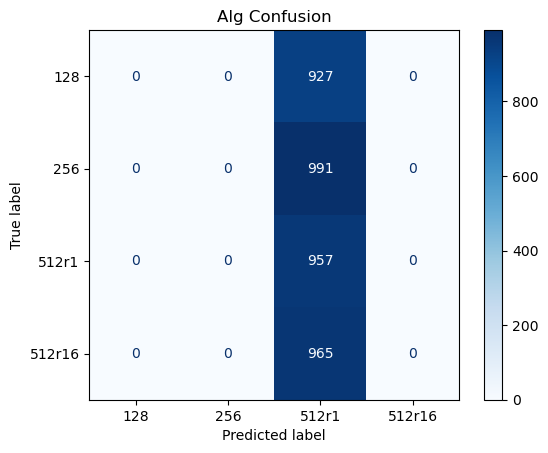

In [131]:
alg_confusion = confusion_matrix(alg_true_label, alg_pred_label, labels=[alg.name for alg in algs])
alg_disp = ConfusionMatrixDisplay(confusion_matrix=alg_confusion, display_labels=[alg.name for alg in algs])
alg_disp.plot(cmap="Blues", values_format = 'd')
plt.title("Alg Confusion")
plt.show()

In [132]:
# pass_probs128 = pass_classifier128.predict(pass128_test_x)
# pass_preds128 = np.array([np.argmax(prob) for prob in pass_probs128])
# print(pass_preds128)
# print(enum_pass_test_targets128)
# pass_inv_mapping = {idx: label for label, idx in pass_mapping.items()}
# pass_true_label128 = [pass_inv_mapping[idx] for idx in enum_pass_test_targets128['password'].to_list()]
# pass_pred_label128 = [pass_inv_mapping[idk] for idk in pass_preds128]

# pass_probs256 = pass_classifier256.predict(pass256_test_x)
# pass_preds256 = np.array([np.argmax(prob) for prob in pass_probs256])
# print(pass_preds256)
# print(enum_pass_test_targets256)
# pass_true_label256 = [pass_inv_mapping[idx] for idx in enum_pass_test_targets256['password'].to_list()]
# pass_pred_label256 = [pass_inv_mapping[idk] for idk in pass_preds256]

pass_probs = [model['model'].predict(model['test_x']) for model in pass_classifiers]
pass_preds = [np.array([np.argmax(prob) for prob in probs]) for probs in pass_probs]
print(pass_preds)
#mapping should be same for all but its convieniant like this
enum_pass_test_targets = [make_mapping(model['test_y'], passwords, 'password') for model in pass_classifiers]
#just grab the first one
pass_inv_mapping = {idx: label for label, idx in enum_pass_test_targets[0][1].items()}
pass_true_labels = [[pass_inv_mapping[idx] for idx in test_targets[0]['password'].to_list()] for test_targets in enum_pass_test_targets]
pass_pred_labels = [[pass_inv_mapping[idk] for idk in pass_pred] for pass_pred in pass_preds]

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step   
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step   
[array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0

/home/andromeda/anaconda3/envs/cryptography/lib/python3.12/site-packages/sklearn/utils/multiclass.py:367: FutureWarning:

Support for labels represented as bytes is deprecated in v1.5 and will error in v1.7. Convert the labels to a string or integer format.

/home/andromeda/anaconda3/envs/cryptography/lib/python3.12/site-packages/sklearn/utils/multiclass.py:367: FutureWarning:

Support for labels represented as bytes is deprecated in v1.5 and will error in v1.7. Convert the labels to a string or integer format.



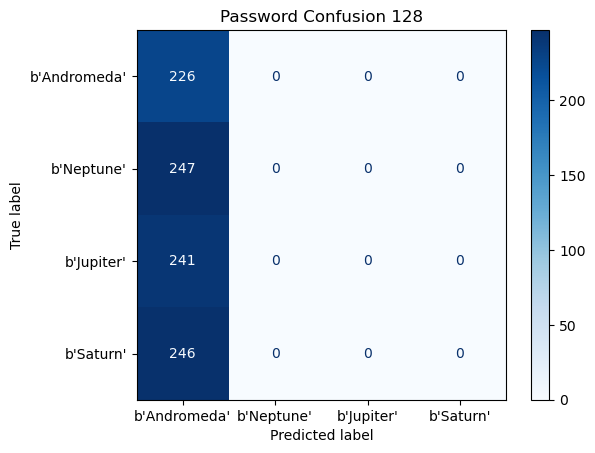

/home/andromeda/anaconda3/envs/cryptography/lib/python3.12/site-packages/sklearn/utils/multiclass.py:367: FutureWarning:

Support for labels represented as bytes is deprecated in v1.5 and will error in v1.7. Convert the labels to a string or integer format.

/home/andromeda/anaconda3/envs/cryptography/lib/python3.12/site-packages/sklearn/utils/multiclass.py:367: FutureWarning:

Support for labels represented as bytes is deprecated in v1.5 and will error in v1.7. Convert the labels to a string or integer format.



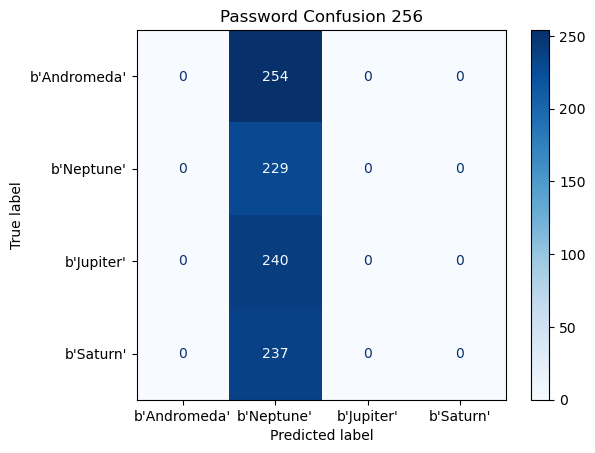

/home/andromeda/anaconda3/envs/cryptography/lib/python3.12/site-packages/sklearn/utils/multiclass.py:367: FutureWarning:

Support for labels represented as bytes is deprecated in v1.5 and will error in v1.7. Convert the labels to a string or integer format.

/home/andromeda/anaconda3/envs/cryptography/lib/python3.12/site-packages/sklearn/utils/multiclass.py:367: FutureWarning:

Support for labels represented as bytes is deprecated in v1.5 and will error in v1.7. Convert the labels to a string or integer format.



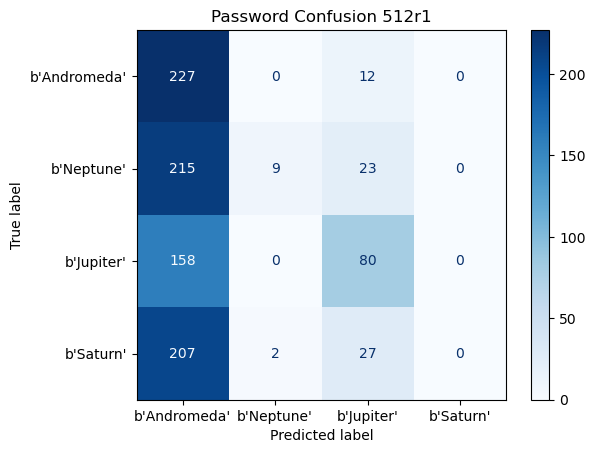

/home/andromeda/anaconda3/envs/cryptography/lib/python3.12/site-packages/sklearn/utils/multiclass.py:367: FutureWarning:

Support for labels represented as bytes is deprecated in v1.5 and will error in v1.7. Convert the labels to a string or integer format.

/home/andromeda/anaconda3/envs/cryptography/lib/python3.12/site-packages/sklearn/utils/multiclass.py:367: FutureWarning:

Support for labels represented as bytes is deprecated in v1.5 and will error in v1.7. Convert the labels to a string or integer format.



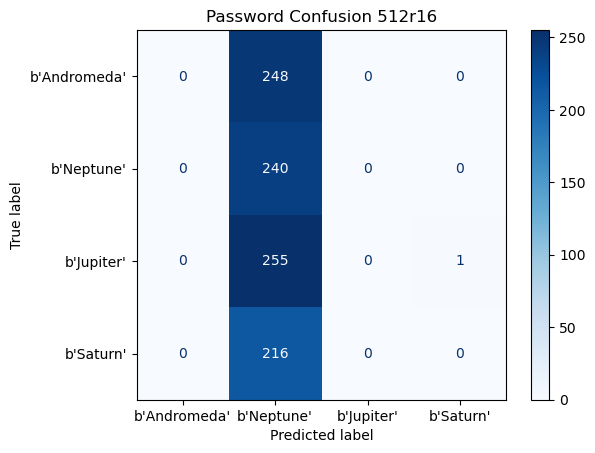

In [133]:
for i in range(len(algs)):
    pass_confusion = confusion_matrix(pass_true_labels[i], pass_pred_labels[i], labels=passwords)
    pass_disp = ConfusionMatrixDisplay(confusion_matrix=pass_confusion, display_labels=passwords)
    pass_disp.plot(cmap="Blues", values_format = 'd')
    plt.title(f"Password Confusion {algs[i].name}")
    plt.show()

In [134]:
# pass_confusion256 = confusion_matrix(pass_true_label256, pass_pred_label256, labels=passwords)
# pass_disp256 = ConfusionMatrixDisplay(confusion_matrix=pass_confusion256, display_labels=passwords)
# pass_disp256.plot(cmap="Blues", values_format = 'd')
# plt.title("Password Confusion 256")
# plt.show()

In [135]:
encoded_data = encoder.predict(np.array(df[x_string].to_list()))

1200/1200 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [136]:
alg_true, alg_map = make_mapping(df, [alg.name for alg in algs], 'alg')
# print(encoded_data[:, 0])
# print(len(encoded_data[:, 0]))
# print(len(encoded_data[:, 1]))
# print(len(encoded_data[:, 2]))
# print(len(alg_true))
# print(len(sc_alg_pred))
# print(alg_true.shape)
# print(sc_alg_pred.shape)
alg_true = alg_true['alg']
# print(np.unique(sc_alg_pred, return_counts = True))

In [142]:
alg_cluster_results = pd.DataFrame({
    'X1': encoded_data[:, 0],
    'X2': encoded_data[:, 1],
    'X3': encoded_data[:, 2],
    'True Label': alg_true
    #'Predicted Cluster': sc_alg_pred
})

fig_true = px.scatter_3d(
    alg_cluster_results, x='X1', y='X2', z='X3',
    color='True Label',
    title='Alg True Labels in Autoencoded 3D Space'
)
fig_true.show()

# fig_pred = px.scatter_3d(
#     alg_cluster_results, x='X1', y='X2', z='X3',
#     color='Predicted Cluster',
#     title='Spectral Clustering in 3D Latent Space'
# )
# fig_pred.show()


In [138]:
pass_true, pass_map = make_mapping(df, passwords, 'password')
# print(encoded_data[:, 0])
# print(len(encoded_data[:, 0]))
# print(len(encoded_data[:, 1]))
# print(len(encoded_data[:, 2]))
# print(len(alg_true))
# print(len(sc_pass_pred))
# print(pass_true.shape)
# print(sc_pass_pred.shape)
pass_true = pass_true['password']
# print(np.unique(sc_pass_pred, return_counts = True))

In [139]:
alg_cluster_results = pd.DataFrame({
    'X1': encoded_data[:, 0],
    'X2': encoded_data[:, 1],
    'X3': encoded_data[:, 2],
    'True Label': pass_true
    #'Predicted Cluster': sc_pass_pred
})

fig_true = px.scatter_3d(
    alg_cluster_results, x='X1', y='X2', z='X3',
    color='True Label',
    title='Password True Labels in Autoencoded 3D Space'
)
fig_true.show()

# fig_pred = px.scatter_3d(
#     alg_cluster_results, x='X1', y='X2', z='X3',
#     color='Predicted Cluster',
#     title='Spectral Clustering in 3D Latent Space'
# )
# fig_pred.show()


In [140]:
alg_probs = alg_classifier.predict(test_data_format)
alg_preds = np.array([np.argmax(prob) for prob in alg_probs])
print(alg_preds)
print(enum_alg_test_targets)
alg_inv_mapping = {idx: label for label, idx in alg_mapping.items()}
alg_true_label = [alg_inv_mapping[idx] for idx in enum_alg_test_targets['alg'].to_list()]
alg_pred_label = [alg_inv_mapping[idk] for idk in alg_preds]

120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[2 2 2 ... 2 2 2]
shape: (3_840, 5)
┌─────┬──────────────┬────────────────────┬────────────────────────────┬───────────────────────────┐
│ alg ┆ password     ┆ source_file        ┆ plaintext                  ┆ combo_text                │
│ --- ┆ ---          ┆ ---                ┆ ---                        ┆ ---                       │
│ i64 ┆ binary       ┆ str                ┆ binary                     ┆ list[list[list[f64]]]     │
╞═════╪══════════════╪════════════════════╪════════════════════════════╪═══════════════════════════╡
│ 1   ┆ b"Andromeda" ┆ Convo21Message1_5  ┆ b"of\x20them\x20assisting\ ┆ [[[0.878431, 0.435294],   │
│     ┆              ┆                    ┆ x20i…                      ┆ [0.811…                   │
│ 1   ┆ b"Saturn"    ┆ Convo38Message2_11 ┆ b"\x20signal\x20intended\x ┆ [[[0.392157, 0.12549],    │
│     ┆              ┆                    ┆ 20to…                      ┆ [0.4196…                  │
│ 2   ┆ b"Nept

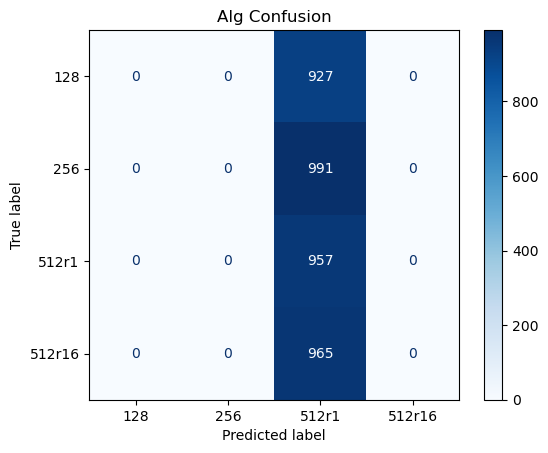

In [141]:
alg_confusion = confusion_matrix(alg_true_label, alg_pred_label, labels=[alg.name for alg in algs])
alg_disp = ConfusionMatrixDisplay(confusion_matrix=alg_confusion, display_labels=[alg.name for alg in algs])
alg_disp.plot(cmap="Blues", values_format = 'd')
plt.title("Alg Confusion")
plt.show()